# 📌 Submission Guidelines

### ✅ File Naming Rule  
Submit your notebook with the following format:

`StudentID_YourFullName_LABXX.ipynb`

or

`StudentID_YourFullName_LABXX.html`

**Examples (Correct):**
- `21113456_NguyenVanA_LAB01.ipynb`
- `19122233_TranThiB_LAB02.ipynb`

**Examples (Wrong → 0 points):**
- `Lab01.ipynb`
- `YourName.ipynb`
- `20123456.ipynb`
- `Lab01.pdf`

---

### 📌 Grading Policy

- ❌ Wrong filename format, missing submission, or plagiarism (code identical to others) → 0 points

- ⚠️ Submitting a file without results, incomplete work, or only the assignment description → Maximum 4 points

- ✅ Correct filename + Completed results → Graded normally based on assignment quality (accuracy, clarity, and originality)  

### Note:
- AI assistance is allowed, but you must write the code yourself. All submissions will be checked for originality.

---


# **Goal:**

Learn to apply different geometric transformations to images, like translation, rotation, affine transformation etc.

# **Transformations**

OpenCV provides two transformation functions, cv.warpAffine and cv.warpPerspective, with which you can perform all kinds of transformations. cv.warpAffine takes a 2x3 transformation matrix while cv.warpPerspective takes a 3x3 transformation matrix as input.

# Code sample

## Download and import library


In [6]:
import pandas as pd
import numpy as np
import cv2 as cv
from cv2 import imwrite, imread
from matplotlib import pyplot as plt

In [7]:
!gdown 13Pn85BtiF7rCyLR7hT8QEqekvUp-Q0s8

'gdown' is not recognized as an internal or external command,
operable program or batch file.


In [8]:
def imshows(ImageData, LabelData, rows, cols, gridType = False):
  # Convert ImageData and LabelData to List
  ImageArray = list(ImageData)
  LabelArray = list(LabelData)
  if(rows == 1 & cols == 1):
    fig = plt.figure(figsize=(20,20))
  else:
    fig = plt.figure(figsize=(cols*8,rows*5))

  for i in range(1, cols * rows + 1):
      fig.add_subplot(rows, cols, i)
      image = ImageArray[i - 1]
      # If the channel number is less than 3, we display as grayscale image
      # otherwise, we display as color image
      if (len(image.shape) < 3):
          plt.imshow(image, plt.cm.gray)
          plt.grid(gridType)
      else:
          plt.imshow(image)
          plt.grid(gridType)
      plt.title(LabelArray[i - 1])
  plt.show()

def ShowFourImages(IM1, IM2, IM3, IM4):
    imshows([IM1, IM2, IM3, IM4], ["Image 1","Image 2", "Image 3", "Image 4"], 2, 2)
def ShowThreeImages(IM1, IM2, IM3):
    imshows([IM1, IM2, IM3], ["Image 1","Image 2", "Image 3"], 1, 3)
def ShowTwoImages(IM1, IM2):
    imshows([IM1, IM2], ["Image 1","Image 2"], 1, 2)
def ShowOneImage(IM):
    imshows([IM], ["Image"], 1, 1)
def ShowListImages(listImage, row, col):
    listCaption = []
    for i in range(len(listImage)):
        listCaption.append(str(i))
    imshows(listImage,listCaption,row,col)

## showing image and information

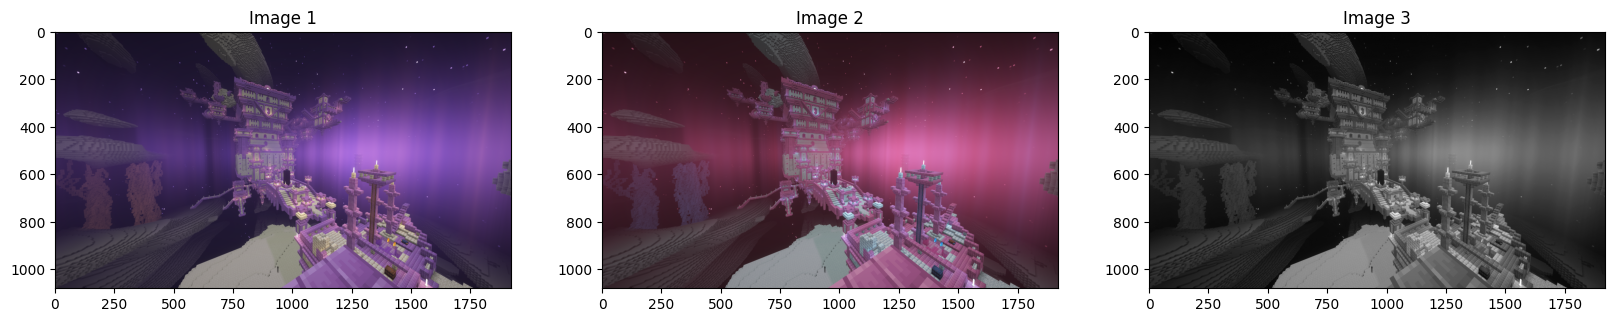

In [9]:
img_path = "/content/pokemon.jpeg"

img_bgr = cv.imread('the end.png')
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
image_gray = cv.cvtColor(img_rgb, cv.COLOR_RGB2GRAY)

ShowThreeImages(img_rgb, img_bgr, image_gray)

In [10]:
# Show Information of Color Image
Image = img_rgb.copy()
Width = Image.shape[1]
Height = Image.shape[0]
Channel = len(Image.shape)

print("Width : ", Width, " Height : ", Height, " Channel : ", Channel)

if(Channel == 2):
    print("Min Intensity: ", Image.min(), " Max Intensity: ", Image.max())
else:
    print("Red - Min Intensity: ", Image[:,:,0].min(), " Max Intensity: ", Image[:,:,0].max())
    print("Green - Min Intensity: ", Image[:,:,1].min(), " Max Intensity: ", Image[:,:,1].max())
    print("Blue - Min Intensity: ", Image[:,:,2].min(), " Max Intensity: ", Image[:,:,2].max())

Width :  1920  Height :  1080  Channel :  3
Red - Min Intensity:  18  Max Intensity:  255
Green - Min Intensity:  13  Max Intensity:  255
Blue - Min Intensity:  25  Max Intensity:  255


In [11]:
# Show Information of Gray Image
Image_gray = image_gray.copy()
Width_gray = Image_gray.shape[1]
Height_gray = Image_gray.shape[0]
Channel_gray = len(Image_gray.shape)
print("Width : ", Width_gray, " Height : ", Height_gray, " Channel : ", Channel_gray)

if(Channel_gray == 2):
    print("Min Intensity: ", Image_gray.min(), " Max Intensity: ", Image_gray.max())
else:
    print("Red - Min Intensity: ", Image_gray[:,:,0].min(), " Max Intensity: ", Image_gray[:,:,0].max())
    print("Green - Min Intensity: ", Image_gray[:,:,1].min(), " Max Intensity: ", Image_gray[:,:,1].max())
    print("Blue - Min Intensity: ", Image_gray[:,:,2].min(), " Max Intensity: ", Image_gray[:,:,2].max())

Width :  1920  Height :  1080  Channel :  2
Min Intensity:  17  Max Intensity:  255


## **Rescale and Resize**

In [12]:
def rescale_image(img, scale=None, new_size=None, interpolation=cv.INTER_CUBIC):
    """
    Resize an image either by scale or by specifying a new size.

    Parameters:
    - img: Input image to resize.
    - scale: Scaling factor for both width and height (e.g., scale=2 will double the size). Optional.
    - new_size: Tuple specifying the new size (width, height) in pixels. Optional.
    - interpolation: Interpolation method (default: cv.INTER_CUBIC).

    Returns:
    - res: Resized image.
    """
    height, width = img.shape[:2]


    if scale is not None:
        scale = tuple(scale)
        res = cv.resize(img, None, fx=scale[0], fy=scale[1], interpolation=interpolation)
    elif new_size is not None:
        res = cv.resize(img, new_size, interpolation=interpolation)
    else:
        raise ValueError("Either scale or new_size must be provided.")

    return res

In [13]:
res1 = rescale_image(img_rgb, scale = (10,10))
res2 = rescale_image(img_rgb, new_size=(int(0.1*Width), int(0.1*Height)))
res3 = rescale_image(img_rgb, new_size=(int(0.5*Width),int(0.5*Width)))

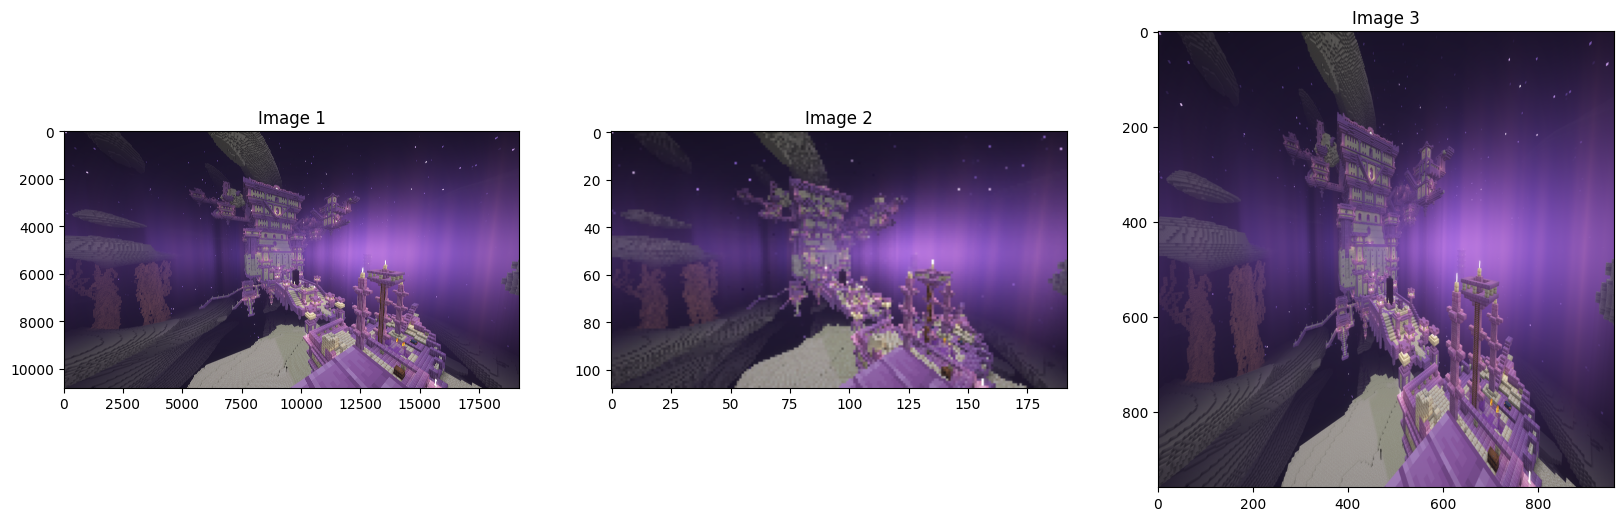

In [14]:
ShowThreeImages(res1, res2, res3)

In [15]:
print("Original Size     :", img_rgb.shape)
print("Rescaled (x10)    :", res1.shape)
print("Rescaled (x0.1)   :", res2.shape)
print("Resize   (0.5)    :", res3.shape)

Original Size     : (1080, 1920, 3)
Rescaled (x10)    : (10800, 19200, 3)
Rescaled (x0.1)   : (108, 192, 3)
Resize   (0.5)    : (960, 960, 3)


## **Translation**

Translation is the shifting of an object's location. If you know the shift in the $(x,y)$ direction and let it be $(t_{x},t_{y})$ you can create the transformation matrix $M$ as follows:

$$
M =
\begin{bmatrix}
1 & 0  & t_{x} \\
0 & 1  & t_{y} \\
\end{bmatrix}
$$

You can take make it into a Numpy array of type np.float32 and pass it into the cv.warpAffine() function. See the below example for a shift of (100,50):




In [16]:
def translate_image(image, x_shift, y_shift):
    (h, w) = image.shape[:2]
    translation_matrix = np.float32([[1, 0, x_shift], [0, 1, y_shift]])
    translated_image = cv.warpAffine(image, translation_matrix, (w, h))
    return translated_image


In [17]:
dst = translate_image(img_rgb, 100, 50)

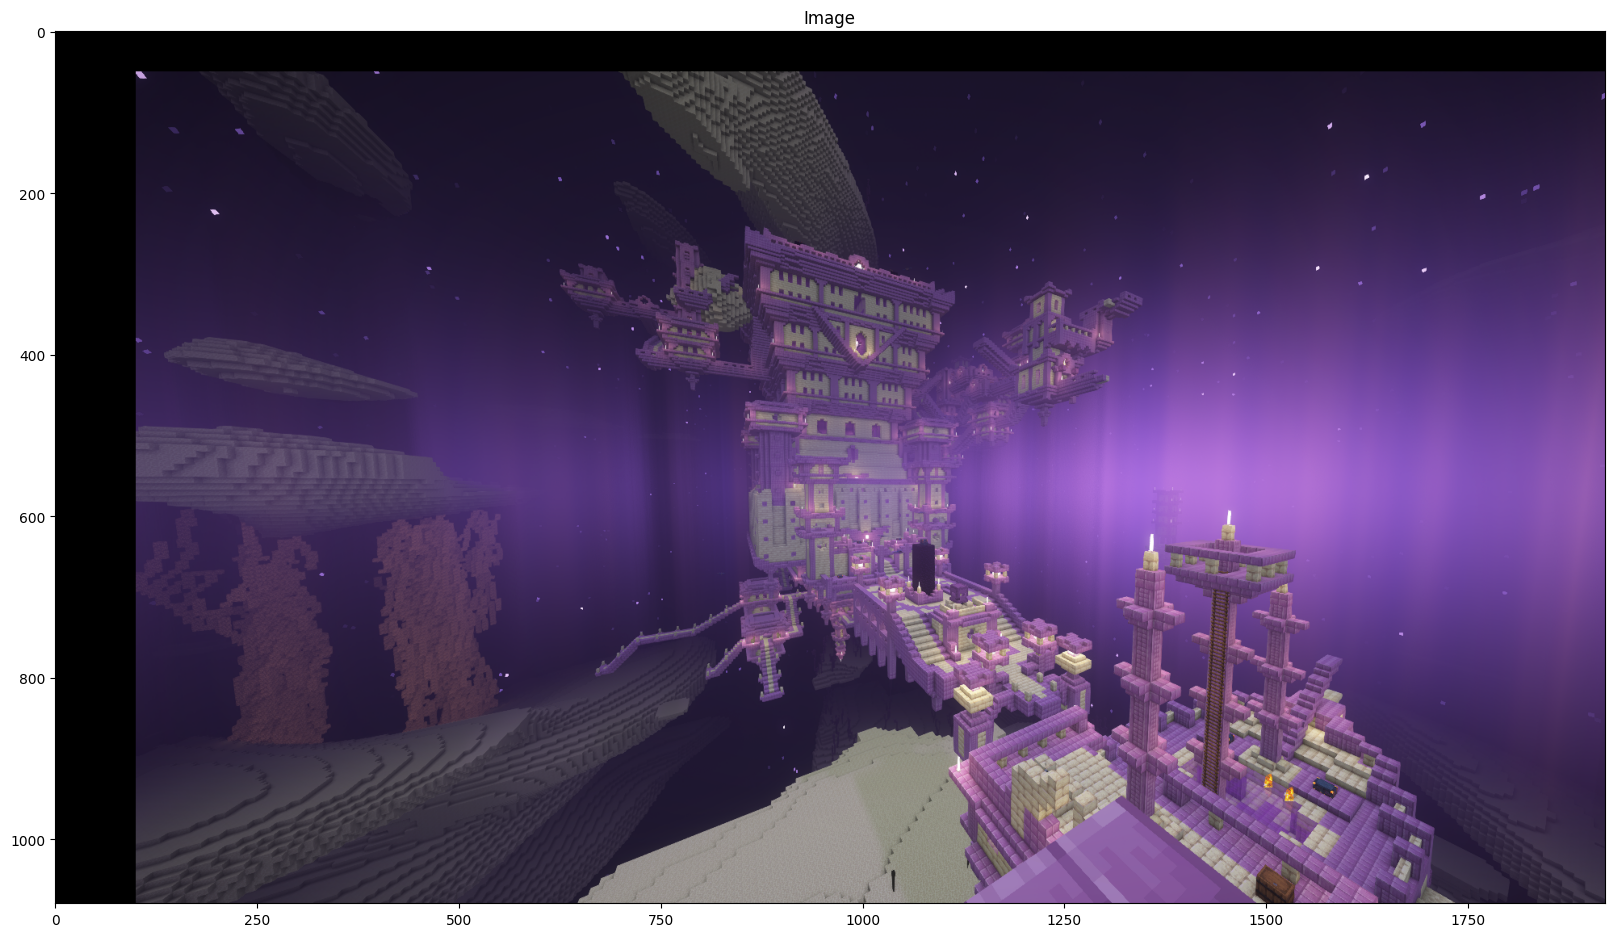

In [18]:
ShowOneImage(dst)
cv.waitKey(0)
cv.destroyAllWindows()

## **Rotation**




Rotation of an image for an angle θ is achieved by the transformation matrix of the form

$$
M = \begin{bmatrix}
\cos{\theta} & -\sin{\theta} \\
\sin{\theta} & \cos{\theta}
\end{bmatrix}
$$

But OpenCV provides scaled rotation with adjustable center of rotation so that you can rotate at any location you prefer. The modified transformation matrix is given by:


\begin{bmatrix}
\alpha & \beta & (1 - \alpha) \cdot \text{center.x} - \beta \cdot \text{center.y} \\
-\beta & \alpha & \beta \cdot \text{center.x} + (1 - \alpha) \cdot \text{center.y}
\end{bmatrix}


where:


$\alpha = \text{scale} \cdot \cos{\theta}, \quad \beta = \text{scale} \cdot \sin{\theta}$


To find this transformation matrix, OpenCV provides a function, `cv.getRotationMatrix2D`. Check out the below example which rotates the image by 90 degrees with respect to the center without any scaling.

In [19]:
def rotate_image(image, angle):
    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)
    rotation_matrix = cv.getRotationMatrix2D(center, angle, 1.0)
    rotated_image = cv.warpAffine(image, rotation_matrix, (w, h))
    return rotated_image

In [20]:
rotated = rotate_image(img_rgb, 90)
print('rotated Dimensions : ',rotated.shape)

rotated Dimensions :  (1080, 1920, 3)


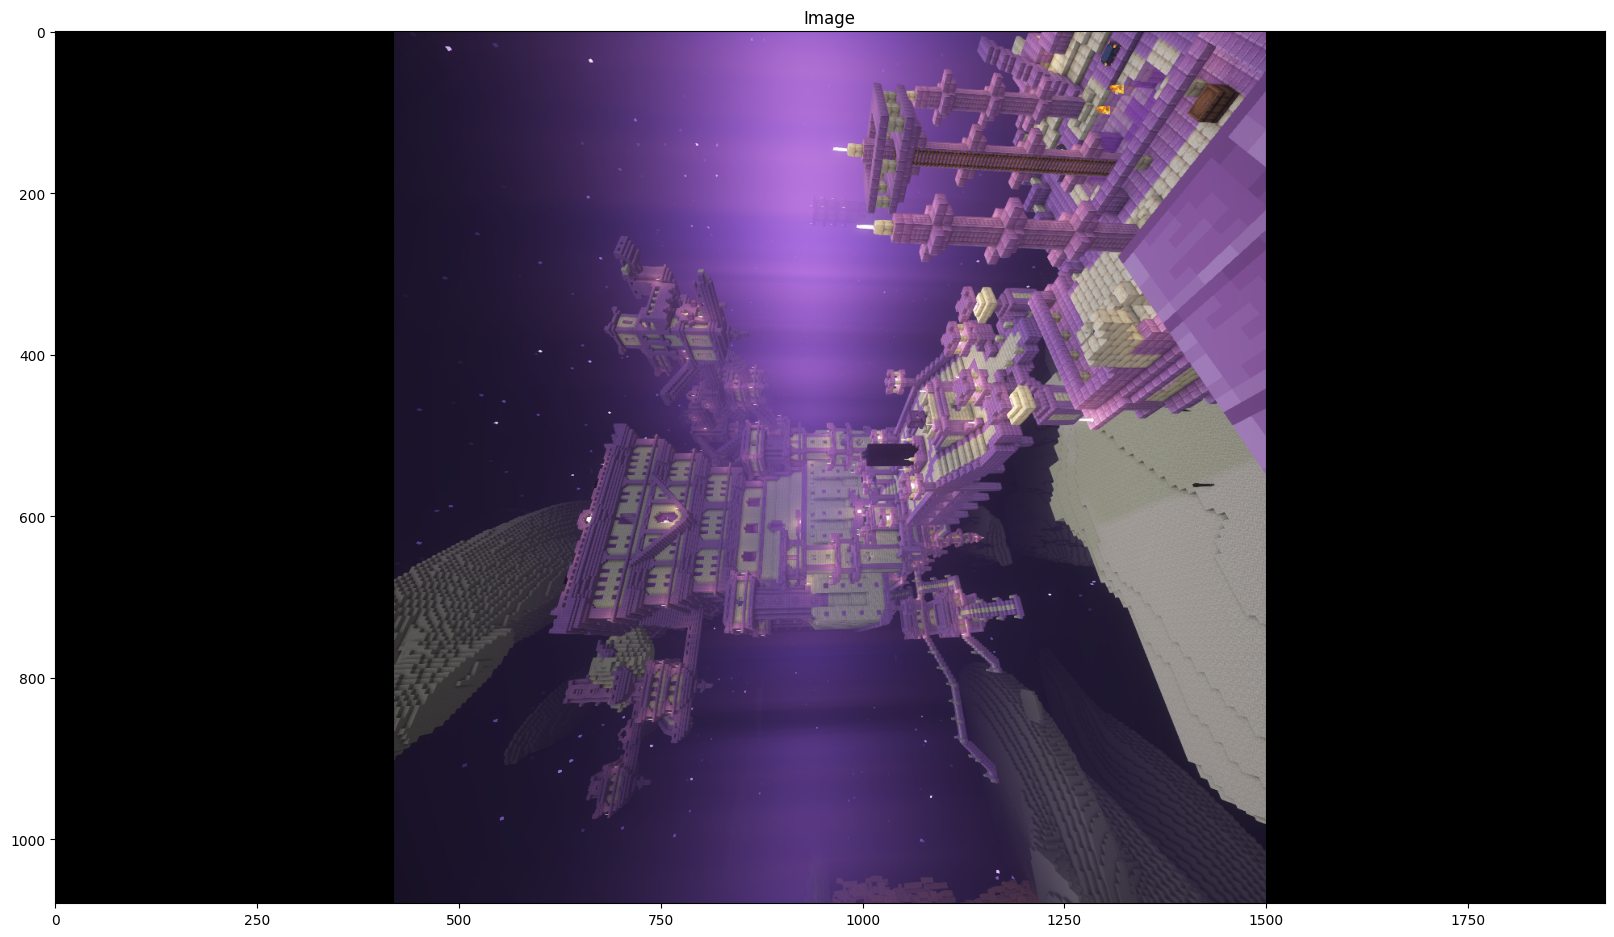

In [21]:
ShowOneImage(rotated)

## **Affine Transformation**

In affine transformation, all parallel lines in the original image will still be parallel in the output image. To find the transformation matrix, we need three points from the input image and their corresponding locations in the output image. Then cv.getAffineTransform will create a 2x3 matrix which is to be passed to cv.warpAffine.

Check the below example, and also look at the points I selected (which are marked in red color):

In [26]:
def affine_transform(image_path, pts1, pts2):
    """
    Applies an affine transformation to the image based on two sets of points.

    Parameters:
    - image_path: Path to the input image.
    - pts1: List of three points in the original image.
    - pts2: List of three points in the output image to map to.

    Returns:
    - dst: The transformed image.
    """
    img = cv.imread(image_path)
    assert img is not None, "File could not be read, check with os.path.exists()"
    rows, cols, ch = img.shape

    # Compute the affine transform matrix
    M = cv.getAffineTransform(np.float32(pts1), np.float32(pts2))
    img_points = img.copy()

    for p in pts1:
      cv.circle(img_points, (int(p[0]), int(p[1])), 5, (0, 0, 255), -1)

    # Apply the affine transformation
    dst = cv.warpAffine(img, M, (cols, rows))

    for p in pts2:
      cv.circle(dst, (int(p[0]), int(p[1])), 5, (0, 0, 255), -1)

    # Display the input and output images
    plt.subplot(121), plt.imshow(cv.cvtColor(img_points, cv.COLOR_BGR2RGB)), plt.title('Input')
    plt.subplot(122), plt.imshow(cv.cvtColor(dst, cv.COLOR_BGR2RGB)), plt.title('Output')
    plt.show()

    return dst

In [27]:
pts1 = [[50, 50], [200, 50], [50, 200]]
pts2 = [[10, 100], [200, 50], [100, 250]]
affine_dst = affine_transform(img_bgr, pts1, pts2)



error: OpenCV(4.12.0) :-1: error: (-5:Bad argument) in function 'imread'
> Overload resolution failed:
>  - Expected 'filename' to be a str or path-like object
>  - Expected 'filename' to be a str or path-like object
>  - Expected 'filename' to be a str or path-like object


## Record Image

In [ ]:
cv.imwrite('affine_transform_image.jpg', affine_dst)

affine_transform = cv.imread('affine_transform_image.jpg')

affine_transform = cv.cvtColor(affine_transform, cv.COLOR_BGR2RGB)

ShowOneImage(affine_transform)

NameError: name 'cv' is not defined

# Homework

## 1. Choose an image from the Internet

  * Load or download an image from the Internet.

## 2. Perform the following operations on the image:
  * Read and display the original image
  * Scale (resize) the image (zoom in / zoom out)
  * Rotate the image by a given angle (30,45,60 (3 images))
  * Translate (shift) the image by some pixels
  * Apply an Affine Transformation
  * Zoom with Cropping
    * When zooming into an image, parts of the image may go beyond the frame.
    * Write code to crop the central region of the zoomed image so that the output size remains the same as the original image.
    * Hint: Use array slicing or **cv2.resize()** after applying the zoom transformation.
  * Save each transformed image with descriptive names

## 3. Advanced Image Transformation Tasks
  * Rotate around an arbitrary point
    * Write a function to rotate an image around a specific point (not the image center).

  * Combine Translation + Rotation
    * Apply a translation (shift) first, then rotate the image.
    * Reverse the order (rotate first, then translate) and compare the results.
    * Observe how the transformation order affects the final image.

  * Inverse Transformation
    * Given an image that has been rotated by 45° and translated 50px to the right,
    * Write a function to restore the original image by applying the inverse transformation.

  * Affine Transform for Data Augmentation
    * Generate 10 distinct augmented versions of the same image using combinations of affine transformations, including:
      * Rotation: randomly within ±10°
      * Scaling (Zoom): randomly zoom in or out by 10–20%
      * Translation: randomly shift the image by ±10 pixels along both x and y axes
      * (Optional) Combine multiple transformations in a single augmentation step to simulate real-world variations.
    * Save and display all augmented images.

  * Image Alignment (Image Registration)
    * Suppose you have two images of the same object but taken at slightly different angles.
    * Find the affine transformation matrix that aligns (registers) the two images.
    * Hint: Use the OpenCV function cv2.estimateAffinePartial2D().

## 4. Apply transformations to each color channel separately (R, G, B).
  * How do slight differences in rotation/scaling per channel affect the reconstructed RGB image?
  * Can this technique simulate color aberration seen in old cameras?

## 5.Report
  * Present the original image alongside all transformed images in a comparative layout.
  * Discuss how different transformations affect image geometry and potential implications for data augmentation or model training.